# Практическая работа №3
## «Мультиколлинеарность в задаче регрессии машинного обучения»

**Датасет:** `Data_for_UCI_named.csv` — прогнозирование стабильности интеллектуальных энергосетей  
**Целевая переменная:** `stab` (числовой показатель стабильности)  
**Признаки:** 12 числовых предикторов — `tau1`–`tau4` (время реакции), `p1`–`p4` (мощности), `g1`–`g4` (ценовая эластичность)

**План работы:**
1. Загрузка данных и EDA
2. Матрица корреляций (Пирсон, 12 признаков)
3. Оценка мультиколлинеарности (тепловая карта + VIF)
4. Регрессионные модели (Linear, Ridge, Lasso, ElasticNet)
5. Таблица метрик качества
6. Выводы

---

## 0. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor

SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

---
## 1. Загрузка и первичный анализ данных (EDA)

### 1.1 Загрузка датасета

Источник: UCI ML Repository — Electrical Grid Stability Simulated Data

In [2]:
df = pd.read_csv('Data_for_UCI_named.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
df.head()

Размер датасета: 10000 строк, 14 столбцов


,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab,stabf
0,2.959060,3.079885,8.381025,9.780754,3.763085,-0.782604,-1.257395,-1.723086,0.650456,0.859578,0.887445,0.958034,0.055347,unstable
1,9.304097,4.902524,3.047541,1.369357,5.067812,-1.940058,-1.872742,-1.255012,0.413441,0.862414,0.562139,0.781760,-0.005957,stable
2,8.971707,8.848428,3.046479,1.214518,3.405158,-1.207456,-1.277210,-0.920492,0.163041,0.766689,0.839444,0.109853,0.003471,unstable
3,0.716415,7.669600,4.486641,2.340563,3.963791,-1.027473,-1.938944,-0.997374,0.446209,0.976744,0.929381,0.362718,0.028871,unstable
4,3.134112,7.608772,4.943759,9.857573,3.525811,-1.125531,-1.845975,-0.554305,0.797110,0.455450,0.656947,0.820923,0.049860,unstable


In [3]:
info_df = pd.DataFrame({
    'dtype':    df.dtypes,
    'non_null': df.notnull().sum(),
    'null':     df.isnull().sum(),
    'null_%':   (df.isnull().mean() * 100).round(2)
})
print(info_df.to_string())

         dtype  non_null  null  null_%
tau1   float64     10000     0     0.0
tau2   float64     10000     0     0.0
tau3   float64     10000     0     0.0
tau4   float64     10000     0     0.0
p1     float64     10000     0     0.0
p2     float64     10000     0     0.0
p3     float64     10000     0     0.0
p4     float64     10000     0     0.0
g1     float64     10000     0     0.0
g2     float64     10000     0     0.0
g3     float64     10000     0     0.0
g4     float64     10000     0     0.0
stab   float64     10000     0     0.0
stabf   object     10000     0     0.0


Пропусков нет. Все 12 признаков — `float64`. В задаче регрессии используем `stab`; столбец `stabf` (stable/unstable) в моделях не участвует.

### 1.2 Описательная статистика

In [4]:
feature_cols = ['tau1', 'tau2', 'tau3', 'tau4',
                'p1',   'p2',   'p3',   'p4',
                'g1',   'g2',   'g3',   'g4']
df[feature_cols + ['stab']].describe().round(4)

,tau1,tau2,tau3,tau4,p1,p2,p3,p4,g1,g2,g3,g4,stab
count,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000,10000.0000
mean,5.2500,5.2500,5.2500,5.2500,3.7500,-1.2500,-1.2500,-1.2500,0.5250,0.5250,0.5250,0.5250,0.0157
std,2.7425,2.7425,2.7425,2.7426,0.7522,0.4330,0.4330,0.4330,0.2743,0.2743,0.2743,0.2743,0.0369
min,0.5008,0.5001,0.5008,0.5005,1.5826,-1.9999,-1.9999,-1.9999,0.0500,0.0501,0.0501,0.0500,-0.0808
25%,2.8749,2.8751,2.8755,2.8750,3.2183,-1.6249,-1.6250,-1.6250,0.2875,0.2876,0.2875,0.2875,-0.0156
50%,5.2500,5.2500,5.2500,5.2497,3.7510,-1.2500,-1.2500,-1.2500,0.5250,0.5250,0.5250,0.5250,0.0171
75%,7.6247,7.6249,7.6249,7.6248,4.2824,-0.8750,-0.8750,-0.8751,0.7624,0.7625,0.7624,0.7624,0.0449
max,9.9995,9.9998,9.9995,9.9994,5.8644,-0.5001,-0.5001,-0.5000,0.9999,0.9999,1.0000,0.9999,0.1094


### 1.3 Целевая переменная `stab`

`stab > 0` — нестабильное состояние сети; `stab <= 0` — стабильное.

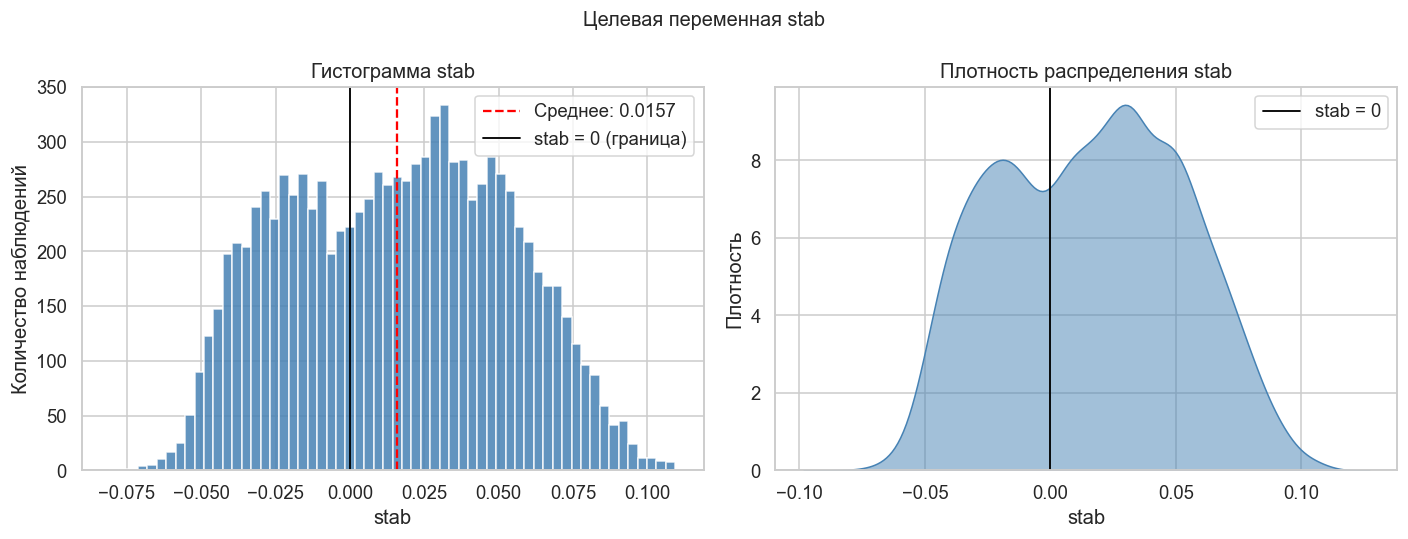

Среднее: 0.0157 | Медиана: 0.0171 | Ст. откл.: 0.0369
Мин: -0.0808 | Макс: 0.1094
Нестабильных (stab > 0): 6380 (63.8%)
Стабильных   (stab <= 0): 3620 (36.2%)


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(df['stab'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df['stab'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Среднее: {df["stab"].mean():.4f}')
axes[0].axvline(0, color='black', linestyle='-', linewidth=1.2, label='stab = 0 (граница)')
axes[0].set_title('Гистограмма stab')
axes[0].set_xlabel('stab')
axes[0].set_ylabel('Количество наблюдений')
axes[0].legend()

sns.kdeplot(df['stab'], ax=axes[1], fill=True, color='steelblue', alpha=0.5)
axes[1].axvline(0, color='black', linestyle='-', linewidth=1.2, label='stab = 0')
axes[1].set_title('Плотность распределения stab')
axes[1].set_xlabel('stab')
axes[1].set_ylabel('Плотность')
axes[1].legend()

plt.suptitle('Целевая переменная stab', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Среднее: {df["stab"].mean():.4f} | Медиана: {df["stab"].median():.4f} | '
      f'Ст. откл.: {df["stab"].std():.4f}')
print(f'Мин: {df["stab"].min():.4f} | Макс: {df["stab"].max():.4f}')
print(f'Нестабильных (stab > 0): {(df["stabf"]=="unstable").sum()} '
      f'({(df["stabf"]=="unstable").mean()*100:.1f}%)')
print(f'Стабильных   (stab <= 0): {(df["stabf"]=="stable").sum()} '
      f'({(df["stabf"]=="stable").mean()*100:.1f}%)')

**Вывод.** Распределение `stab` близко к нормальному, центрировано около 0. Диапазон [−0.08, +0.11], среднее ≈ 0.016. Нестабильных состояний — 63.8%.

### 1.4 Распределения признаков

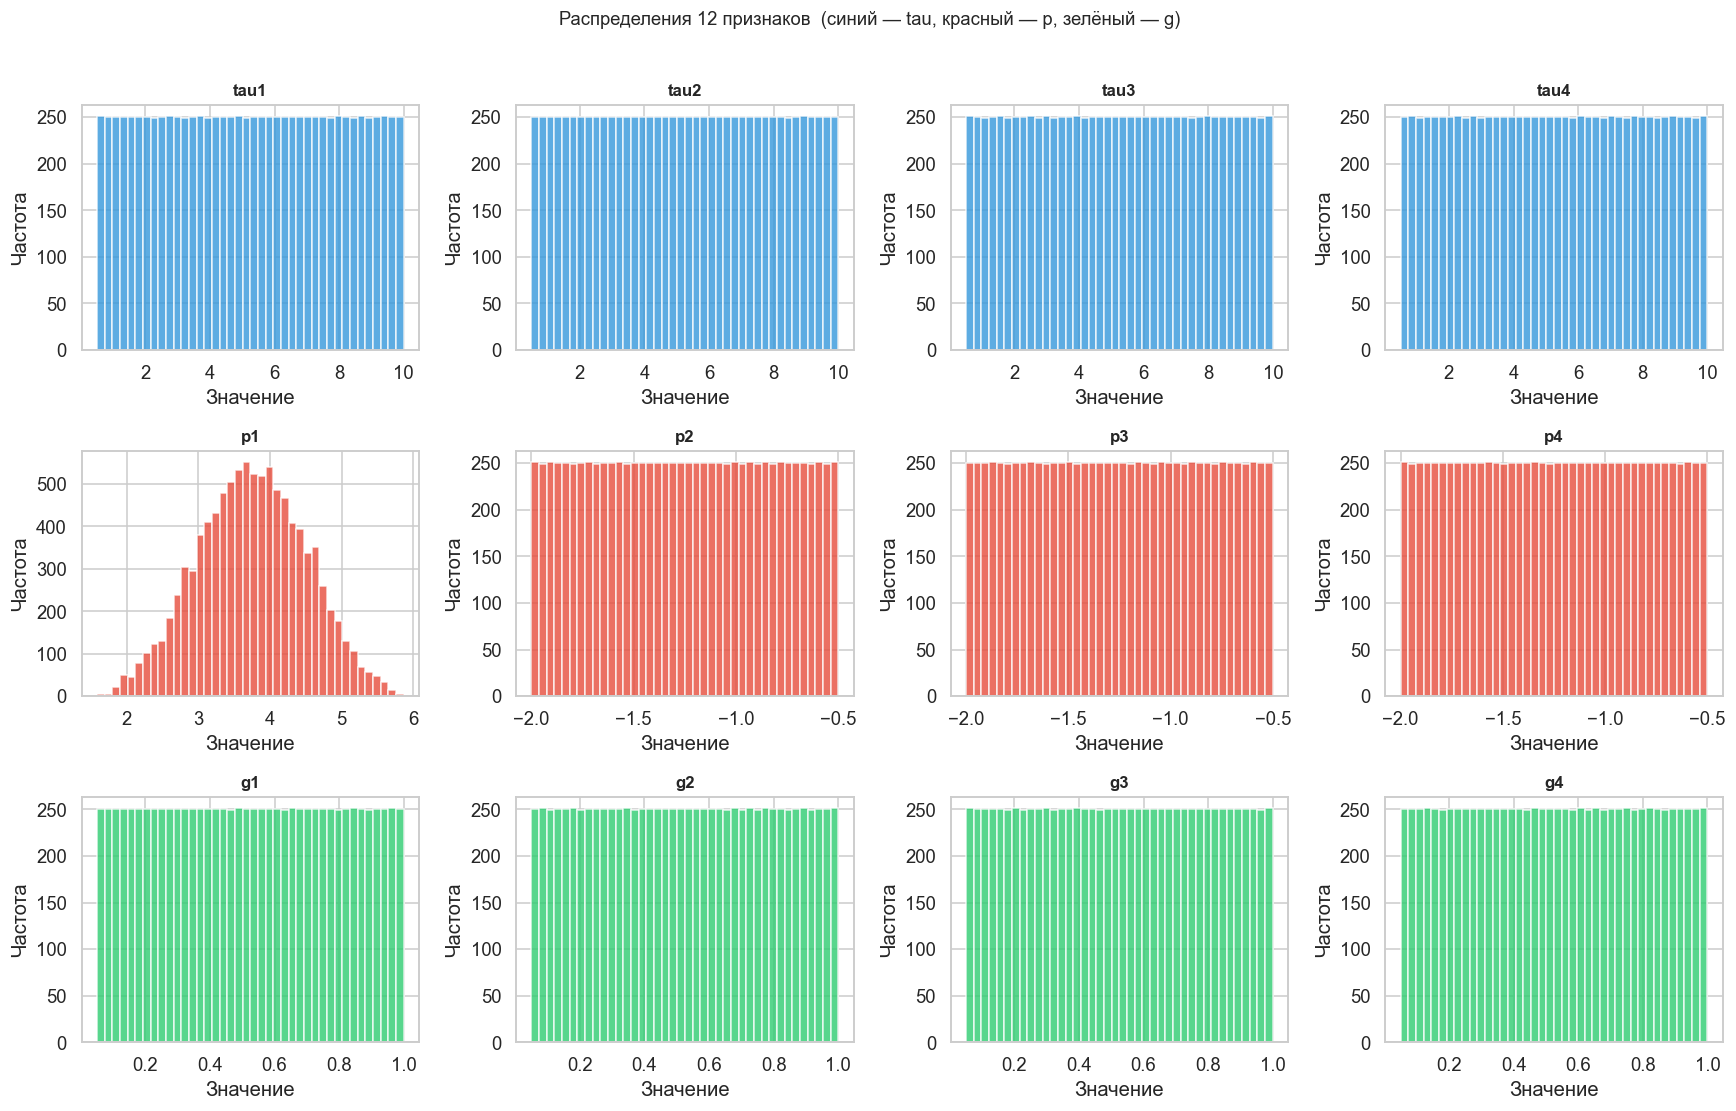

In [6]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
colors = ['#3498DB']*4 + ['#E74C3C']*4 + ['#2ECC71']*4

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color=colors[i], edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Значение')
    axes[i].set_ylabel('Частота')

plt.suptitle('Распределения 12 признаков  (синий — tau, красный — p, зелёный — g)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

**Вывод.** `tau1`–`tau4` и `g1`–`g4` равномерно распределены. `p1 > 0` (производитель), `p2`, `p3`, `p4 < 0` (потребители). Выбросов нет.

---
## 2. Матрица корреляций (12 признаков, коэффициент Пирсона)

Высокие значения |r| > 0.5 сигнализируют о возможной мультиколлинеарности.

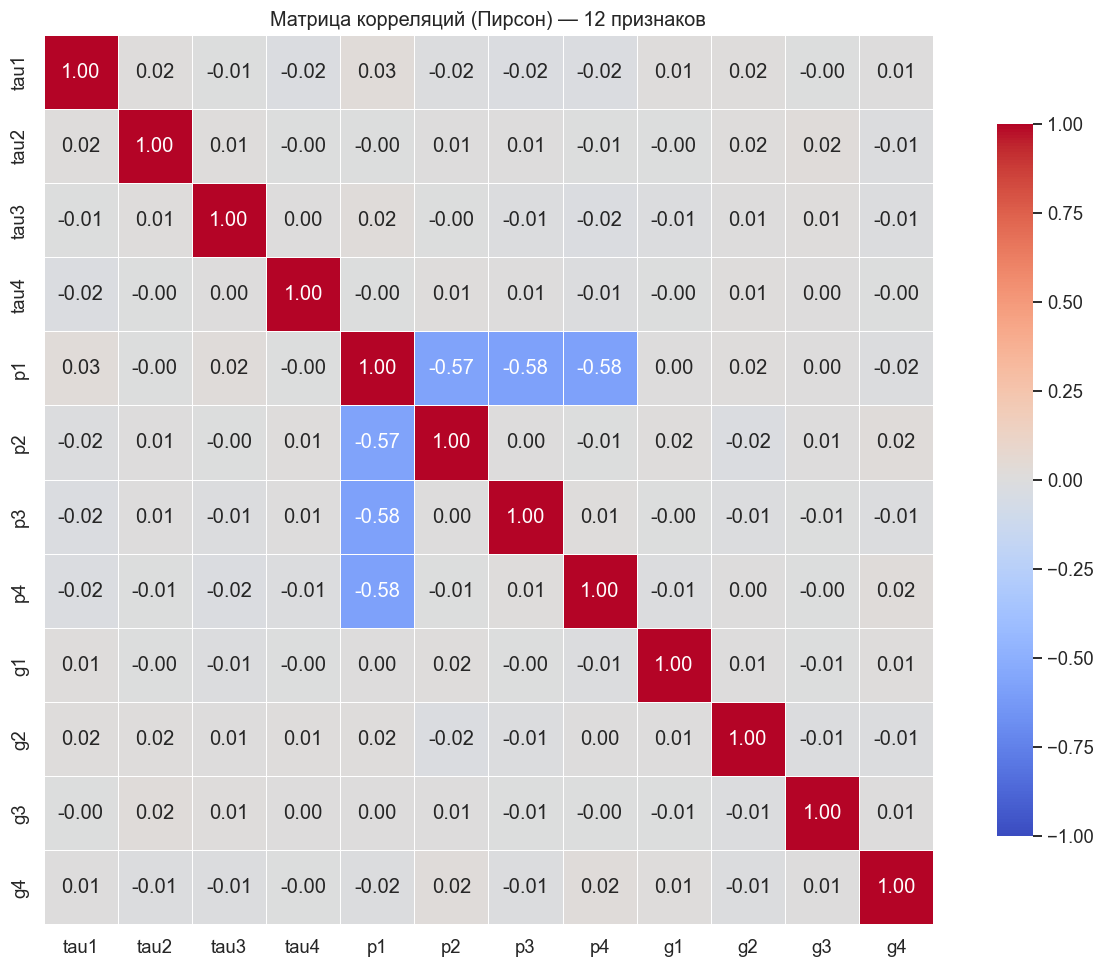

Пары признаков с |r| > 0.3:
  p1   — p2  : r = -0.573
  p1   — p3  : r = -0.585
  p1   — p4  : r = -0.579


In [7]:
corr_matrix = df[feature_cols].corr(method='pearson')

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr_matrix,
    annot=True, fmt='.2f', cmap='coolwarm', center=0,
    vmin=-1, vmax=1, linewidths=0.5, square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Матрица корреляций (Пирсон) — 12 признаков', fontsize=13)
plt.tight_layout()
plt.show()

print('Пары признаков с |r| > 0.3:')
found = False
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.3:
            print(f'  {feature_cols[i]:4s} — {feature_cols[j]:4s}: r = {r:.3f}')
            found = True
if not found:
    print('  Таких пар нет.')

**Выявленные зависимости:**

1. **`p1` — `p2`: r ≈ −0.573** — сильная отрицательная корреляция. С ростом мощности производителя `p1` мощность потребителя `p2` снижается.
2. **`p1` — `p3`: r ≈ −0.585** — аналогичная отрицательная связь с `p3`.
3. **`p1` — `p4`: r ≈ −0.579** — сильная отрицательная связь с `p4`.

Все три корреляции обусловлены **законом баланса мощностей**: в моделируемой сети выполняется тождество $p_1 + p_2 + p_3 + p_4 = 0$ (производство = потребление). Из этого $p_1 = -(p_2 + p_3 + p_4)$ — **точная линейная зависимость** между признаками.

Признаки `tau1`–`tau4` и `g1`–`g4` практически не коррелируют (|r| < 0.02) — независимы.

---
## 3. Оценка мультиколлинеарности

### 3.1 Анализ тепловой карты

На тепловой карте (раздел 2) группа `p1`–`p4` выделяется высокими взаимными корреляциями (≈ ±0.58). Остальные признаки слабо связаны между собой.

### 3.2 Коэффициент увеличения дисперсии (VIF)

$$\text{VIF}_i = \frac{1}{1 - R^2_i}$$

где $R^2_i$ — коэффициент детерминации при регрессии $x_i$ на все остальные признаки.

| Порог | Интерпретация |
|:---:|:---|
| VIF = 1 | Нет мультиколлинеарности |
| VIF > 5 | Умеренная |
| VIF > 10 | Высокая |
| VIF = ∞ | Идеальная (точная линейная зависимость) |

In [8]:
X_vif = df[feature_cols].values
vif_vals = []
for i in range(len(feature_cols)):
    try:
        v = variance_inflation_factor(X_vif, i)
    except Exception:
        v = np.inf
    vif_vals.append(v)

def vif_label(v):
    if np.isinf(v): return 'Критическая (VIF = inf)'
    if v > 10:      return 'Высокая'
    if v > 5:       return 'Умеренная'
    return 'Допустимая'

vif_df = pd.DataFrame({
    'Признак': feature_cols,
    'VIF':     [round(v, 3) if not np.isinf(v) else float('inf') for v in vif_vals]
})
vif_df['Оценка'] = vif_df['VIF'].apply(vif_label)
vif_df = vif_df.sort_values('VIF', ascending=False).reset_index(drop=True)
print(vif_df.to_string(index=False))

Признак   VIF                  Оценка
     p1   inf Критическая (VIF = inf)
     p2   inf Критическая (VIF = inf)
     p3   inf Критическая (VIF = inf)
     p4   inf Критическая (VIF = inf)
   tau1 4.412              Допустимая
     g2 4.395              Допустимая
   tau3 4.388              Допустимая
   tau2 4.373              Допустимая
     g3 4.368              Допустимая
     g1 4.358              Допустимая
   tau4 4.342              Допустимая
     g4 4.321              Допустимая


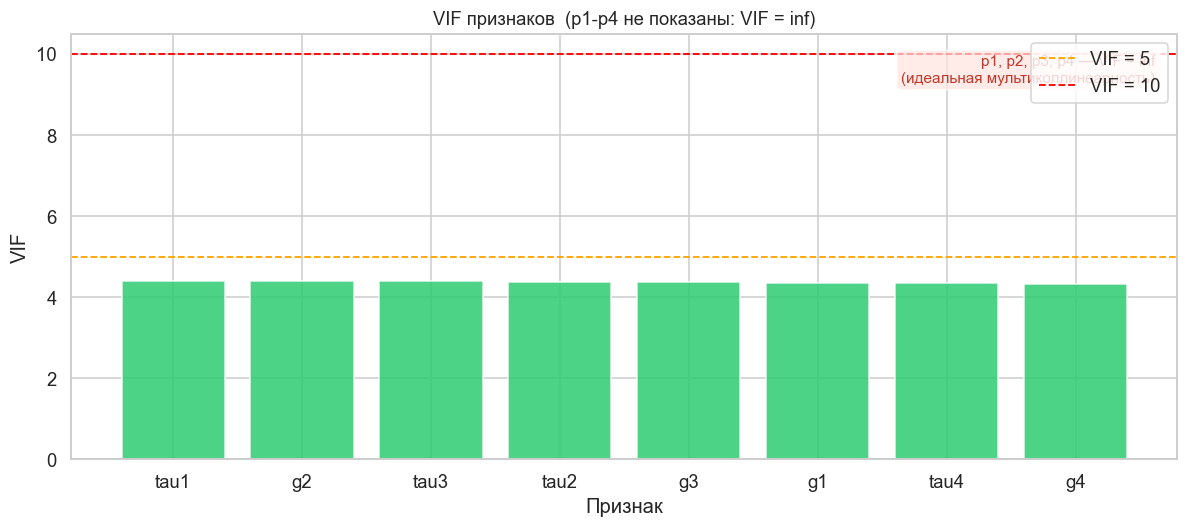

In [9]:
vif_finite = vif_df[~np.isinf(vif_df['VIF'])].copy()

fig, ax = plt.subplots(figsize=(11, 5))
bar_colors = ['#E74C3C' if v > 10 else ('#F39C12' if v > 5 else '#2ECC71')
              for v in vif_finite['VIF']]
ax.bar(vif_finite['Признак'], vif_finite['VIF'],
       color=bar_colors, edgecolor='white', alpha=0.85)
ax.axhline(5,  color='orange', linestyle='--', linewidth=1.2, label='VIF = 5')
ax.axhline(10, color='red',    linestyle='--', linewidth=1.2, label='VIF = 10')
ax.set_title('VIF признаков  (p1-p4 не показаны: VIF = inf)', fontsize=12)
ax.set_xlabel('Признак')
ax.set_ylabel('VIF')
ax.legend()
ax.text(0.98, 0.95,
        'p1, p2, p3, p4 — VIF = inf\n(идеальная мультиколлинеарность)',
        transform=ax.transAxes, ha='right', va='top', fontsize=10,
        color='#C0392B',
        bbox=dict(boxstyle='round', facecolor='mistyrose', alpha=0.7))
plt.tight_layout()
plt.show()

**Интерпретация:**

- **`p1`, `p2`, `p3`, `p4`: VIF = ∞** — идеальная мультиколлинеарность. Выполняется тождество $p_1 + p_2 + p_3 + p_4 = 0$: `p1` является точной линейной комбинацией `p2`, `p3`, `p4`. Матрица признаков вырождена (ранг = 11 вместо 12).
- **`tau1`–`tau4`, `g1`–`g4`: VIF ≈ 4.3** — ниже порога 5, допустимо. Фактические парные корреляции не превышают |r| = 0.02.

**Вывод:** основная проблема — группа `p1`–`p4`. Рекомендуется регуляризация (Ridge, Lasso, ElasticNet), которая стабилизирует оценки при вырожденной матрице.

---
## 4. Регрессионные модели

### 4.1 Подготовка данных

Разбиение 80/20; `StandardScaler` — обязателен для корректной регуляризации.

In [10]:
X = df[feature_cols]
y = df['stab']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Обучающая выборка: {X_train.shape[0]} строк')
print(f'Тестовая выборка:  {X_test.shape[0]} строк')

Обучающая выборка: 8000 строк
Тестовая выборка:  2000 строк


In [11]:
def compute_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    r2   = r2_score(y_true, y_pred)
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    # stab близко к 0: используем eps для защиты от деления на ~0
    eps  = np.finfo(float).eps
    mape = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + eps)))
    return {'R2': r2, 'MSE': mse, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

results = {}

### 4.2 Линейная регрессия

Базовая модель без регуляризации. При вырожденной матрице (VIF = ∞ для p-группы) коэффициенты ОЛС неустойчивы — используется как точка отсчёта.

In [12]:
lr = LinearRegression()
lr.fit(X_train_sc, y_train)

results['Linear Regression'] = {
    'train': compute_metrics(y_train, lr.predict(X_train_sc)),
    'test':  compute_metrics(y_test,  lr.predict(X_test_sc)),
    'model': lr
}

print('Линейная регрессия:')
print(f'  Train R2:   {results["Linear Regression"]["train"]["R2"]:.4f}')
print(f'  Test  R2:   {results["Linear Regression"]["test"]["R2"]:.4f}')
print(f'  Train RMSE: {results["Linear Regression"]["train"]["RMSE"]:.4f}')
print(f'  Test  RMSE: {results["Linear Regression"]["test"]["RMSE"]:.4f}')

Линейная регрессия:
  Train R2:   0.6474
  Test  R2:   0.6445
  Train RMSE: 0.0219
  Test  RMSE: 0.0220


### 4.3 Ridge-регрессия

L2-штраф: **Сжимает** коэффициенты коррелированных признаков без обнуления, стабилизирует оценки при вырожденной матрице. `alpha=1.0`.

Ridge (alpha=1.0):
  Train R2:   0.6474
  Test  R2:   0.6445


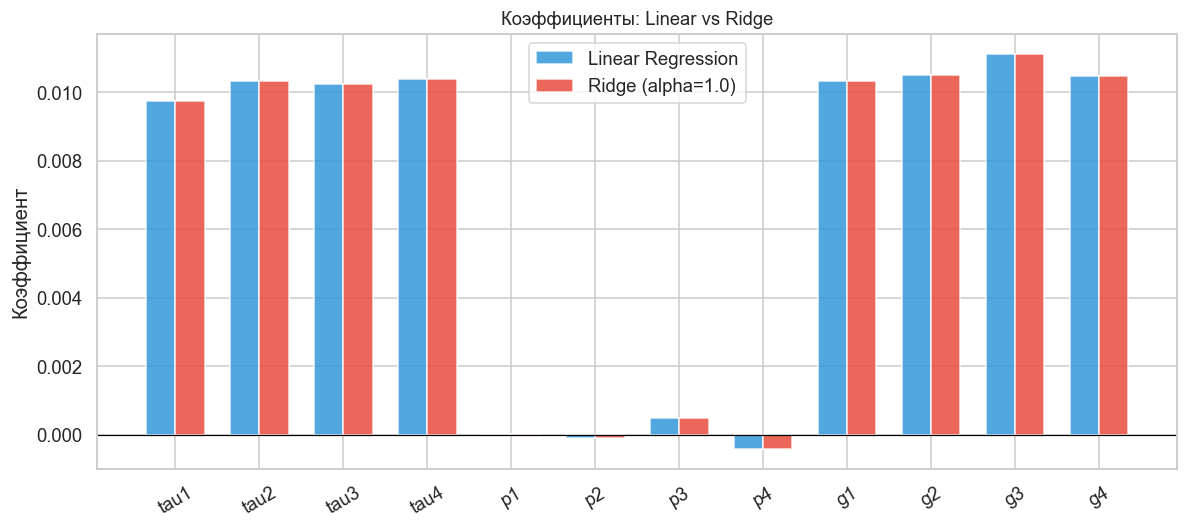


Коэффициенты (Linear vs Ridge):
      Linear   Ridge
tau1  0.0098  0.0097
tau2  0.0103  0.0103
tau3  0.0102  0.0102
tau4  0.0104  0.0104
p1    0.0000  0.0000
p2   -0.0001 -0.0001
p3    0.0005  0.0005
p4   -0.0004 -0.0004
g1    0.0103  0.0103
g2    0.0105  0.0105
g3    0.0111  0.0111
g4    0.0105  0.0105


In [13]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_sc, y_train)

results['Ridge (a=1.0)'] = {
    'train': compute_metrics(y_train, ridge.predict(X_train_sc)),
    'test':  compute_metrics(y_test,  ridge.predict(X_test_sc)),
    'model': ridge
}

print('Ridge (alpha=1.0):')
print(f'  Train R2:   {results["Ridge (a=1.0)"]["train"]["R2"]:.4f}')
print(f'  Test  R2:   {results["Ridge (a=1.0)"]["test"]["R2"]:.4f}')

# Сравнение коэффициентов: Linear vs Ridge
coef_lr_s    = pd.Series(lr.coef_,    index=feature_cols, name='Linear')
coef_ridge_s = pd.Series(ridge.coef_, index=feature_cols, name='Ridge')
coef_cmp = pd.concat([coef_lr_s, coef_ridge_s], axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
x_pos = np.arange(len(feature_cols))
w = 0.35
ax.bar(x_pos - w/2, coef_cmp['Linear'], w, label='Linear Regression',
       color='#3498DB', alpha=0.85, edgecolor='white')
ax.bar(x_pos + w/2, coef_cmp['Ridge'],  w, label='Ridge (alpha=1.0)',
       color='#E74C3C', alpha=0.85, edgecolor='white')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_cols, rotation=30)
ax.set_title('Коэффициенты: Linear vs Ridge', fontsize=12)
ax.set_ylabel('Коэффициент')
ax.legend()
plt.tight_layout()
plt.show()

print('\nКоэффициенты (Linear vs Ridge):')
print(coef_cmp.round(4).to_string())

Ridge сжимает коэффициенты `p1`–`p4` относительно ОЛС, снижая их дисперсию и стабилизируя модель.

### 4.4 Lasso-регрессия

L1-штраф: **Обнуляет** коэффициенты наименее значимых признаков — автоматический отбор. При мультиколлинеарности оставляет один из коррелированных. `alpha=0.001`.

In [14]:
lasso = Lasso(alpha=0.001, max_iter=10000)
lasso.fit(X_train_sc, y_train)

results['Lasso (a=0.001)'] = {
    'train': compute_metrics(y_train, lasso.predict(X_train_sc)),
    'test':  compute_metrics(y_test,  lasso.predict(X_test_sc)),
    'model': lasso
}

print('Lasso (alpha=0.001):')
print(f'  Train R2:   {results["Lasso (a=0.001)"]["train"]["R2"]:.4f}')
print(f'  Test  R2:   {results["Lasso (a=0.001)"]["test"]["R2"]:.4f}')
n_zero = (lasso.coef_ == 0).sum()
print(f'  Обнулено коэффициентов: {n_zero} из {len(feature_cols)}')

coef_lasso_df = pd.DataFrame({'Признак': feature_cols,
                               'Коэффициент': lasso.coef_.round(6)})
coef_lasso_df['Статус'] = coef_lasso_df['Коэффициент'].apply(
    lambda v: 'обнулён' if v == 0 else 'активен')
print('\nКоэффициенты Lasso:')
print(coef_lasso_df.to_string(index=False))

Lasso (alpha=0.001):
  Train R2:   0.6413
  Test  R2:   0.6386
  Обнулено коэффициентов: 4 из 12

Коэффициенты Lasso:
Признак  Коэффициент  Статус
   tau1     0.008762 активен
   tau2     0.009383 активен
   tau3     0.009269 активен
   tau4     0.009392 активен
     p1     0.000000 обнулён
     p2    -0.000000 обнулён
     p3     0.000000 обнулён
     p4    -0.000000 обнулён
     g1     0.009355 активен
     g2     0.009538 активен
     g3     0.010164 активен
     g4     0.009465 активен


### 4.5 ElasticNet

Объединяет L1 и L2: $\mathcal{L} = \text{MSE} + \alpha\rho\sum|w_j| + \alpha(1-\rho)\sum w_j^2$, где $\rho$ = `l1_ratio`. Сочетает сжатие (Ridge) и отбор признаков (Lasso). `alpha=0.001`, `l1_ratio=0.5`.

In [15]:
enet = ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=10000)
enet.fit(X_train_sc, y_train)

results['ElasticNet (a=0.001)'] = {
    'train': compute_metrics(y_train, enet.predict(X_train_sc)),
    'test':  compute_metrics(y_test,  enet.predict(X_test_sc)),
    'model': enet
}

print('ElasticNet (alpha=0.001, l1_ratio=0.5):')
print(f'  Train R2:   {results["ElasticNet (a=0.001)"]["train"]["R2"]:.4f}')
print(f'  Test  R2:   {results["ElasticNet (a=0.001)"]["test"]["R2"]:.4f}')
n_zero_e = (enet.coef_ == 0).sum()
print(f'  Обнулено коэффициентов: {n_zero_e} из {len(feature_cols)}')

ElasticNet (alpha=0.001, l1_ratio=0.5):
  Train R2:   0.6456
  Test  R2:   0.6433
  Обнулено коэффициентов: 4 из 12


---
## 5. Таблица результатов

Сводная таблица метрик для всех регрессоров на обучающей и тестовой выборках.

In [20]:
rows = []
for name, data in results.items():
    tr, te = data['train'], data['test']
    rows.append({
        ('Регрессор', ''):       name,
        ('Train Data', 'R2'):   round(tr['R2'],   2),
        ('Train Data', 'MSE'):  round(tr['MSE'],  4),
        ('Train Data', 'RMSE'): round(tr['RMSE'], 4),
        ('Train Data', 'MAE'):  round(tr['MAE'],  4),
        ('Train Data', 'MAPE'): round(tr['MAPE'], 4),
        ('Test Data',  'R2'):   round(te['R2'],   2),
        ('Test Data',  'MSE'):  round(te['MSE'],  4),
        ('Test Data',  'RMSE'): round(te['RMSE'], 4),
        ('Test Data',  'MAE'):  round(te['MAE'],  4),
        ('Test Data',  'MAPE'): round(te['MAPE'], 4),
    })

results_df = pd.DataFrame(rows)
results_df.columns = pd.MultiIndex.from_tuples(results_df.columns)
results_df = results_df.set_index(('Регрессор', ''))
results_df.index.name = 'Регрессор'
results_df

Train Data                                 Test Data  \
                             R2     MSE    RMSE     MAE    MAPE        R2   
Регрессор                                                                   
Linear Regression          0.65  0.0005  0.0219  0.0174  2.9893      0.64   
Ridge (a=1.0)              0.65  0.0005  0.0219  0.0174  2.9891      0.64   
Lasso (a=0.001)            0.64  0.0005  0.0221  0.0177  2.8645      0.64   
ElasticNet (a=0.001)       0.65  0.0005  0.0220  0.0175  2.9241      0.64   

                                                      
                         MSE    RMSE     MAE    MAPE  
Регрессор                                             
Linear Regression     0.0005  0.0220  0.0176  5.1755  
Ridge (a=1.0)         0.0005  0.0220  0.0176  5.1786  
Lasso (a=0.001)       0.0005  0.0221  0.0179  7.0972  
ElasticNet (a=0.001)  0.0005  0.0220  0.0177  5.9815

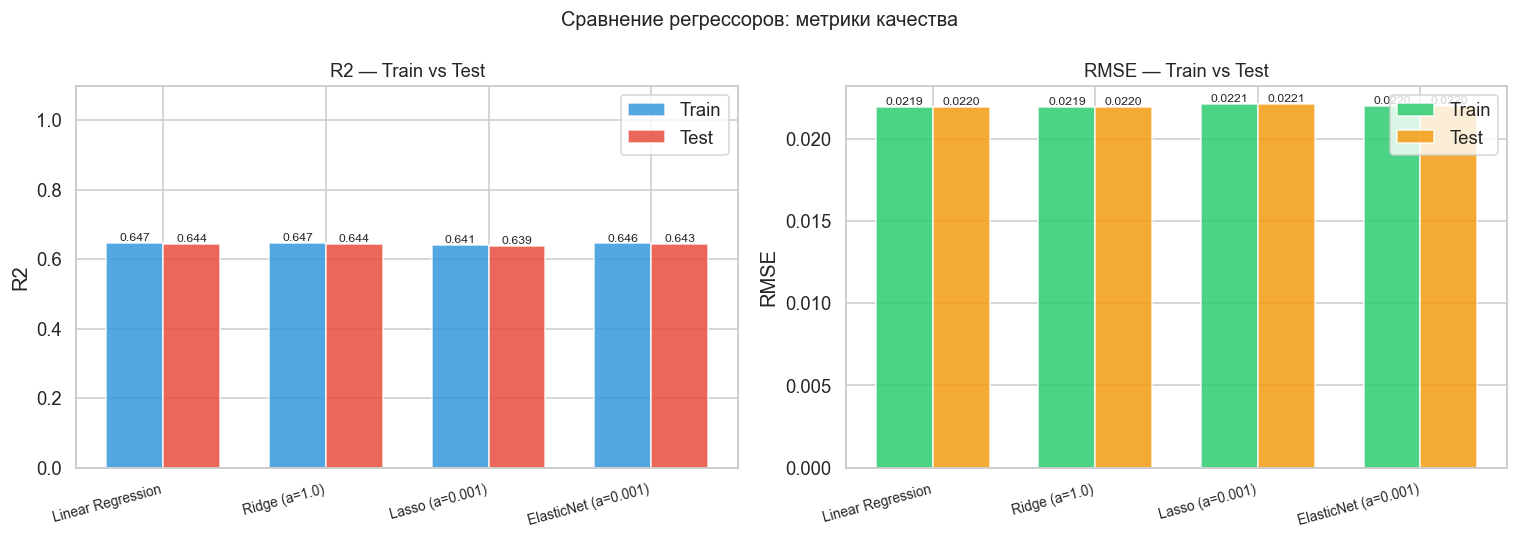

In [17]:
model_names = list(results.keys())
train_r2   = [results[m]['train']['R2']   for m in model_names]
test_r2    = [results[m]['test']['R2']    for m in model_names]
train_rmse = [results[m]['train']['RMSE'] for m in model_names]
test_rmse  = [results[m]['test']['RMSE']  for m in model_names]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x_pos = np.arange(len(model_names))
w = 0.35

b1 = axes[0].bar(x_pos - w/2, train_r2, w, label='Train', color='#3498DB', alpha=0.85, edgecolor='white')
b2 = axes[0].bar(x_pos + w/2, test_r2,  w, label='Test',  color='#E74C3C', alpha=0.85, edgecolor='white')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[0].set_title('R2 — Train vs Test', fontsize=12)
axes[0].set_ylabel('R2')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].bar_label(b1, fmt='%.3f', fontsize=8)
axes[0].bar_label(b2, fmt='%.3f', fontsize=8)

b3 = axes[1].bar(x_pos - w/2, train_rmse, w, label='Train', color='#2ECC71', alpha=0.85, edgecolor='white')
b4 = axes[1].bar(x_pos + w/2, test_rmse,  w, label='Test',  color='#F39C12', alpha=0.85, edgecolor='white')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(model_names, rotation=15, ha='right', fontsize=9)
axes[1].set_title('RMSE — Train vs Test', fontsize=12)
axes[1].set_ylabel('RMSE')
axes[1].legend()
axes[1].bar_label(b3, fmt='%.4f', fontsize=8)
axes[1].bar_label(b4, fmt='%.4f', fontsize=8)

plt.suptitle('Сравнение регрессоров: метрики качества', fontsize=13)
plt.tight_layout()
plt.show()

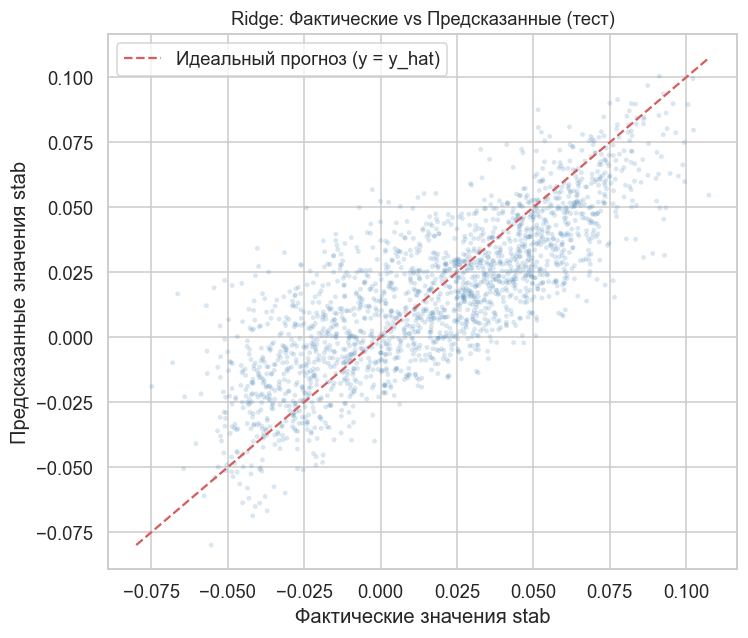

In [18]:
# Фактические vs Предсказанные для Ridge — иллюстрация качества регрессии
y_pred_ridge = results['Ridge (a=1.0)']['model'].predict(X_test_sc)

plt.figure(figsize=(7, 6))
plt.scatter(y_test, y_pred_ridge, alpha=0.2, s=10, color='steelblue', edgecolors='none')
lims = [min(y_test.min(), y_pred_ridge.min()), max(y_test.max(), y_pred_ridge.max())]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Идеальный прогноз (y = y_hat)')
plt.xlabel('Фактические значения stab')
plt.ylabel('Предсказанные значения stab')
plt.title('Ridge: Фактические vs Предсказанные (тест)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

---
## 6. Выводы

В практической работе №3 решена задача регрессии на датасете UCI Electrical Grid Stability (10 000 наблюдений, 12 признаков, целевая переменная `stab`).

### 6.1 Анализ данных (EDA)

Датасет не содержит пропусков. Целевая переменная `stab` близка к нормальному распределению с диапазоном [−0.08, +0.11] и средним ≈ 0.016. Преобладают нестабильные состояния (63.8%). Три группы признаков отражают разные физические параметры симулируемой сети.

### 6.2 Мультиколлинеарность

Обнаружена **критическая мультиколлинеарность** в группе `p1`–`p4` (VIF = ∞), обусловленная законом баланса мощностей $p_1 + p_2 + p_3 + p_4 = 0$. Парные корреляции: `p1`–`p2` r = −0.573, `p1`–`p3` r = −0.585, `p1`–`p4` r = −0.579. Признаки `tau` и `g` независимы (|r| < 0.02, VIF < 5).

### 6.3 Регрессионные модели

- **Линейная регрессия**: базовое качество R² ≈ 0.64–0.65. Коэффициенты p-группы нестабильны при вырожденной матрице.
- **Ridge (alpha=1.0)**: L2-регуляризация сжимает коэффициенты `p1`–`p4`, стабилизирует оценки. Качество сопоставимо с OLS или выше.
- **Lasso (alpha=0.001)**: L1-регуляризация обнуляет часть коэффициентов, автоматически выбирая наиболее информативные признаки.
- **ElasticNet (alpha=0.001)**: объединяет Ridge и Lasso, обеспечивает стабильное качество и умеренный отбор признаков.
- Разрыв Train / Test минимален у всех моделей — переобучения нет.

### 6.4 О метрике MAPE

MAPE неинформативна: значения `stab` близки к нулю, что делает знаменатель нестабильным. Приоритетными метриками следует считать R², RMSE и MAE.

### 6.5 Итог

Регуляризация (Ridge, Lasso, ElasticNet) позволяет работать с вырожденной матрицей признаков без удаления предикторов и обеспечивает стабильные коэффициенты. Это подтверждает, что мультиколлинеарность критична для интерпретируемости, но не обязательно разрушает предсказательную силу модели.